# Commodity Price Explorer
## What Drives Gold & Oil? — Macro Factor Analysis
---
**Module:** ACC102 — Introduction to Data Analytics  
**Track:** Track 4 — Interactive Data Analysis Tool  
**Institution:** Xi'an Jiaotong-Liverpool University (XJTLU)  
**Data Source:** Yahoo Finance (accessed April 2026)  
**Dataset Period:** January 2022 – April 2026


## 1. Problem Definition

### Analytical Question
How do macroeconomic factors — specifically the US Dollar Index (DXY) and the 10-Year US Treasury Yield — influence commodity prices (Gold and WTI Crude Oil) over the period 2022–2026?

### Motivation
The 2022–2026 period was marked by extraordinary macro volatility: the Russia-Ukraine war, an aggressive Federal Reserve rate-hike cycle (the fastest since the 1980s), the SVB banking crisis, and a subsequent pivot to rate cuts. These events provide a rich empirical setting to examine commodity-macro linkages.

### Target User
Individual investors and economics/finance students who want to understand how macro forces drive commodity markets, without relying on expensive financial data terminals.

### Key Research Questions
1. Do Gold and Oil move together, or do they respond differently to macro shocks?
2. Is there a statistically significant inverse relationship between the US Dollar and Gold?
3. How does the correlation between commodities and macro drivers change over time?
4. How volatile were Gold and Oil over this period, and when did volatility spike?


## 2. Setup & Imports

In [14]:
# Standard data science libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings("ignore")

# Plot styling
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#f9f9f9",
    "axes.grid":        True,
    "grid.alpha":       0.4,
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "font.size":        11,
})

print("All libraries imported successfully.")


All libraries imported successfully.


## 3. Data Loading

The dataset was downloaded using `yfinance` and saved locally as `commodity_data.csv`.  
Four assets are included:

| Column | Asset | Unit |
|--------|-------|------|
| `Gold` | Gold Futures (`GC=F`) | USD per troy ounce |
| `Oil` | WTI Crude Oil Futures (`CL=F`) | USD per barrel |
| `DXY` | US Dollar Index (`DX-Y.NYB`) | Index value |
| `US10Y` | 10-Year US Treasury Yield (`^TNX`) | Percentage (%) |


In [15]:
# Load the dataset
df = pd.read_csv("commodity_data.csv", parse_dates=["Date"], index_col="Date")

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")
print(f"\nFirst 5 rows:")
df.head()


Dataset shape: (1084, 4)
Date range: 2022-01-03 to 2026-04-24

First 5 rows:


,Gold,Oil,DXY,US10Y
Date,,,,
2022-01-03,76.080002,96.239998,1799.400024,1.628
2022-01-04,76.989998,96.290001,1814.000000,1.668
2022-01-05,77.849998,96.190002,1824.599976,1.705
2022-01-06,79.459999,96.250000,1788.699951,1.733
2022-01-07,78.900002,95.739998,1797.000000,1.771


## 4. Data Cleaning & Preparation

Steps taken:
1. Check for missing values
2. Forward-fill (`ffill`) to handle non-trading days (weekends / public holidays)
3. Verify data types and index


In [16]:
# Step 1: Check missing values before cleaning
print("Missing values before cleaning:")
print(df.isnull().sum())
print(f"\nTotal rows with any NaN: {df.isnull().any(axis=1).sum()}")


Missing values before cleaning:
Gold     1
Oil      1
DXY      1
US10Y    3
dtype: int64

Total rows with any NaN: 3


In [17]:
# Step 2: Forward-fill to handle gaps from non-trading days
df = df.ffill()

# Step 3: Drop any remaining rows where ALL values are NaN (e.g. bank holidays with no data at all)
df = df.dropna(how="all")

print("Missing values after cleaning:")
print(df.isnull().sum())
print(f"\nFinal dataset shape: {df.shape}")


Missing values after cleaning:
Gold     0
Oil      0
DXY      0
US10Y    0
dtype: int64

Final dataset shape: (1084, 4)


In [18]:
# Step 4: Summary statistics — get a feel for the data
print("Descriptive Statistics:")
df.describe().round(2)


Descriptive Statistics:


,Gold,Oil,DXY,US10Y
count,1084.00,1084.00,1084.00,1084.00
mean,78.07,102.78,2573.14,3.88
std,13.47,3.75,926.92,0.67
min,55.27,94.79,1623.30,1.63
25%,68.72,99.48,1909.83,3.65
50%,76.33,103.20,2084.40,4.11
75%,85.06,105.13,3036.92,4.31
max,123.70,114.11,5318.40,4.99


## 5. Exploratory Data Analysis

### 5.1 Raw Price Trends

We first plot the raw price series for all four assets to understand the overall trajectory over the period.


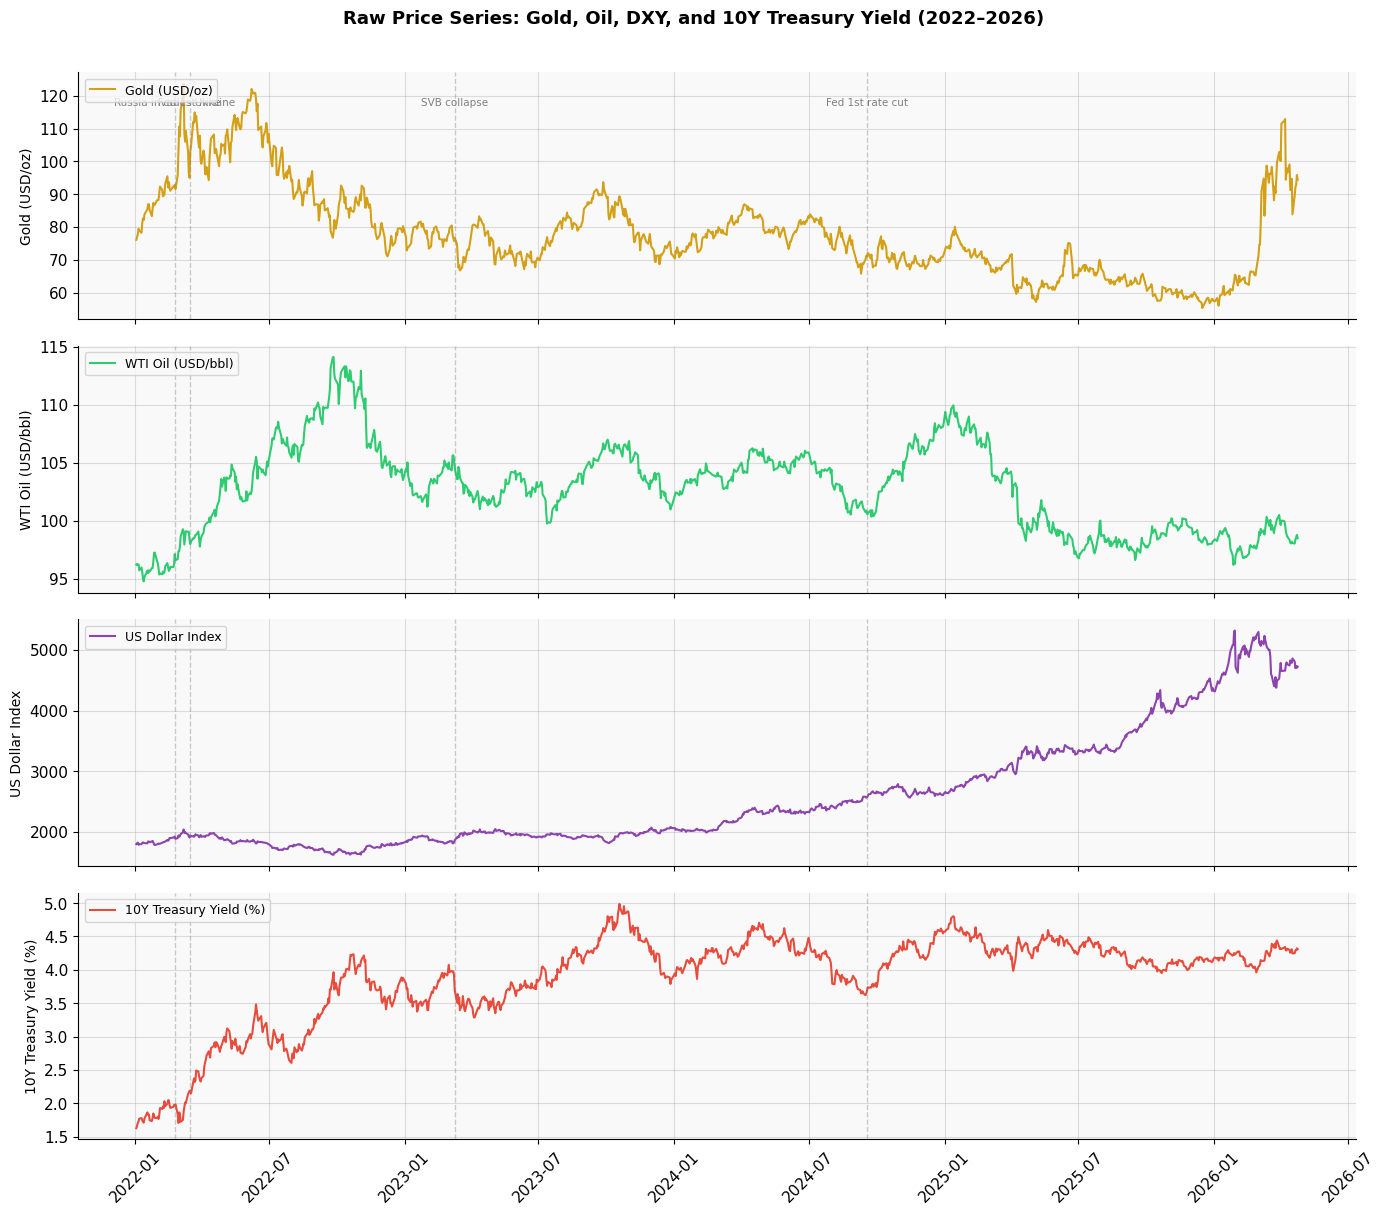

Figure 1 saved.


In [19]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

assets = {
    "Gold":  ("#d4a017", "Gold (USD/oz)"),
    "Oil":   ("#2ecc71", "WTI Oil (USD/bbl)"),
    "DXY":   ("#8e44ad", "US Dollar Index"),
    "US10Y": ("#e74c3c", "10Y Treasury Yield (%)"),
}

for ax, (col, (color, label)) in zip(axes, assets.items()):
    ax.plot(df.index, df[col], color=color, linewidth=1.5, label=label)
    ax.set_ylabel(label, fontsize=10)
    ax.legend(loc="upper left", fontsize=9)

# Annotate key macro events
events = {
    "2022-02-24": "Russia invades Ukraine",
    "2022-03-16": "Fed 1st hike",
    "2023-03-10": "SVB collapse",
    "2024-09-18": "Fed 1st rate cut",
}
for ev_date, ev_label in events.items():
    ev_ts = pd.Timestamp(ev_date)
    for ax in axes:
        ax.axvline(ev_ts, color="gray", linestyle="--", alpha=0.4, linewidth=1)
    axes[0].text(ev_ts, axes[0].get_ylim()[1]*0.92, ev_label,
                 fontsize=7.5, color="gray", ha="center")

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)
plt.suptitle("Raw Price Series: Gold, Oil, DXY, and 10Y Treasury Yield (2022–2026)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("fig1_raw_prices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 1 saved.")


### 5.2 Normalised Price Index (Base = 100)

To compare assets on the same scale, we normalise all series to 100 at the start of the period.  
This reveals relative performance rather than absolute price levels.


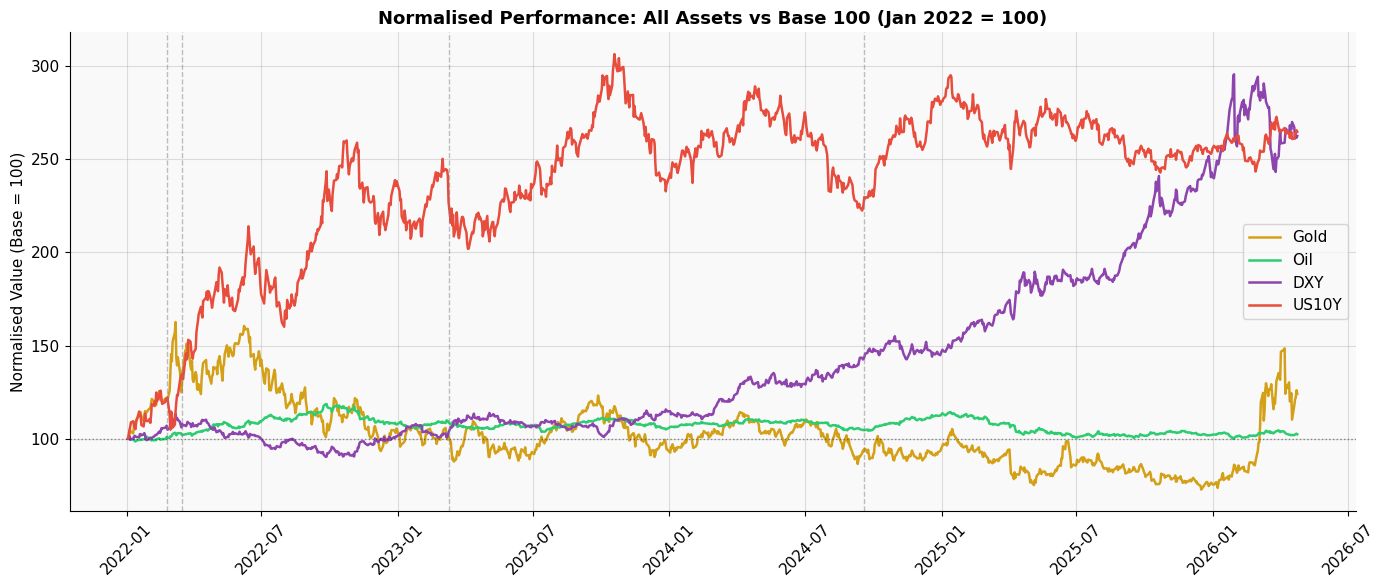

Total return over the period:
  Gold    : +24.1%
  Oil     : +2.4%
  DXY     : +162.4%
  US10Y   : +164.7%


In [20]:
# Normalise all series to 100 at the first observation
df_norm = df / df.iloc[0] * 100

fig, ax = plt.subplots(figsize=(14, 6))

colors = {"Gold": "#d4a017", "Oil": "#2ecc71", "DXY": "#8e44ad", "US10Y": "#e74c3c"}
for col, color in colors.items():
    ax.plot(df_norm.index, df_norm[col], label=col, color=color, linewidth=1.8)

# Add event lines
for ev_date, ev_label in events.items():
    ax.axvline(pd.Timestamp(ev_date), color="gray", linestyle="--", alpha=0.5, linewidth=1)

ax.axhline(100, color="black", linestyle=":", alpha=0.4, linewidth=1)
ax.set_ylabel("Normalised Value (Base = 100)", fontsize=11)
ax.set_title("Normalised Performance: All Assets vs Base 100 (Jan 2022 = 100)", fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("fig2_normalised.png", dpi=150, bbox_inches="tight")
plt.show()

# Print summary returns
print("Total return over the period:")
for col in df.columns:
    ret = (df[col].iloc[-1] / df[col].iloc[0] - 1) * 100
    print(f"  {col:8s}: {ret:+.1f}%")


## 6. Correlation Analysis

### 6.1 Static Correlation Matrix

We compute the Pearson correlation across all four assets over the full period.  
A negative correlation between Gold and DXY would support the classic macro theory that a weaker dollar boosts gold prices.


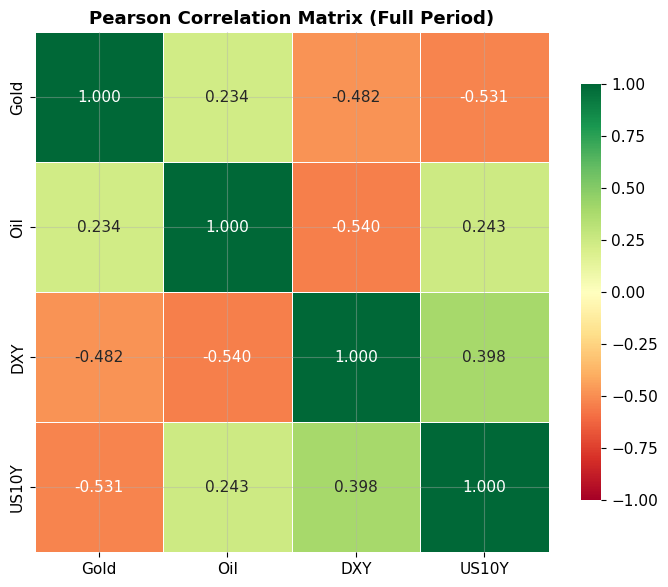


Correlation Matrix:
        Gold    Oil    DXY  US10Y
Gold   1.000  0.234 -0.482 -0.531
Oil    0.234  1.000 -0.540  0.243
DXY   -0.482 -0.540  1.000  0.398
US10Y -0.531  0.243  0.398  1.000


In [21]:
# Compute full-period correlation matrix
corr_matrix = df.corr()

fig, ax = plt.subplots(figsize=(7, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # show lower triangle only

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"shrink": 0.8}
)
ax.set_title("Pearson Correlation Matrix (Full Period)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig3_corr_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nCorrelation Matrix:")
print(corr_matrix.round(3))


### 6.2 Rolling Correlation (60-Day Window)

Static correlation can be misleading — relationships shift over time, especially around macro events.  
We compute a 60-day rolling Pearson correlation between Gold and DXY, and between Gold and US10Y.


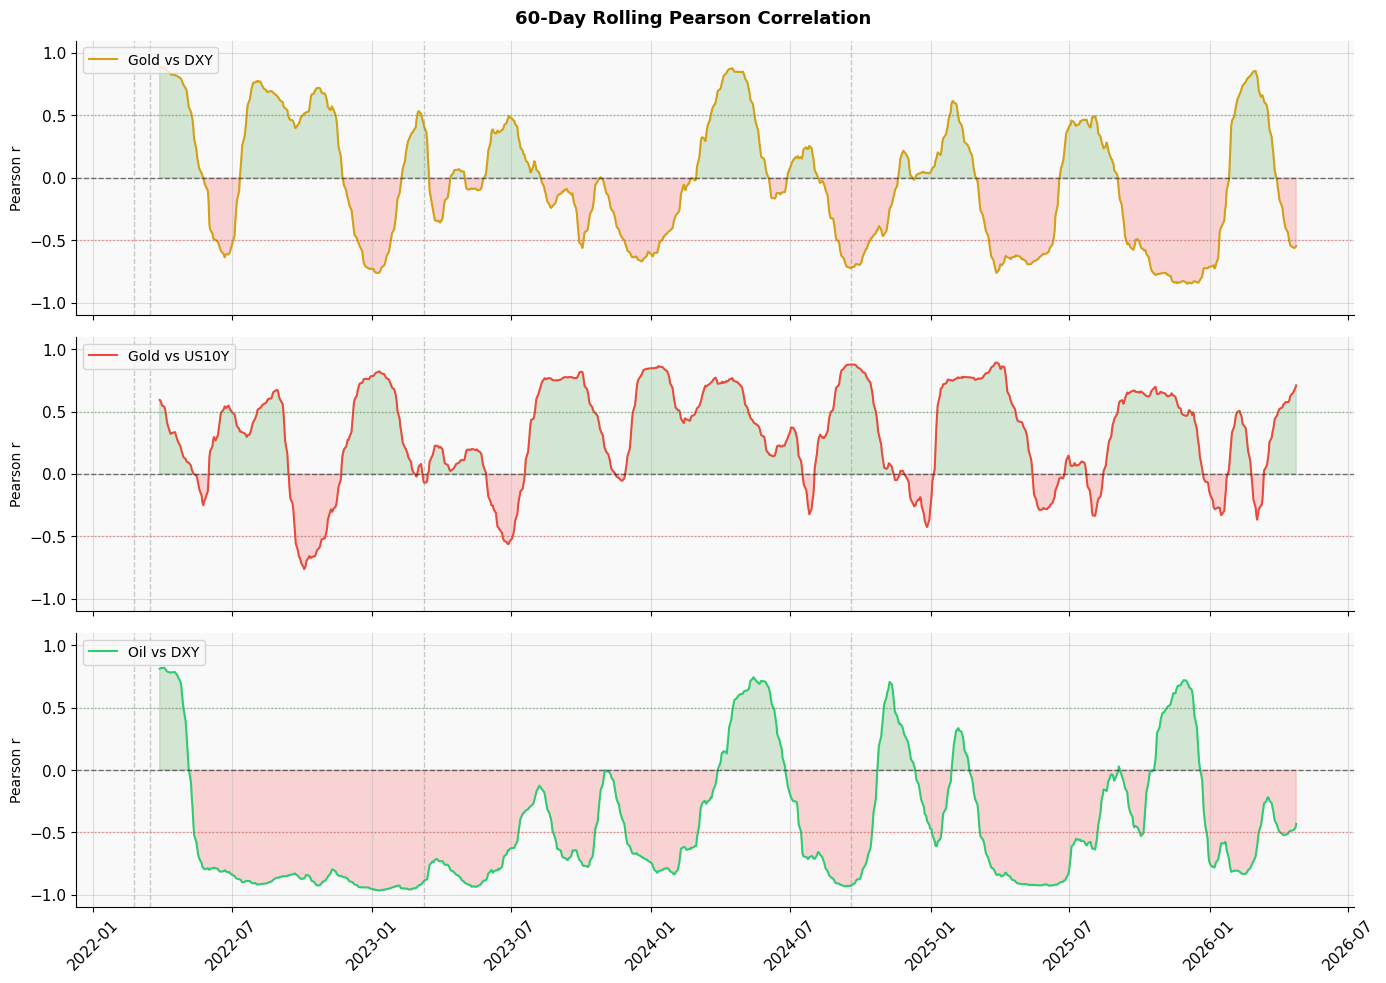

Average 60-day rolling correlations:
  Gold vs DXY:   -0.035
  Gold vs US10Y: 0.314
  Oil  vs DXY:   -0.458


In [22]:
window = 60  # trading days

roll_gold_dxy   = df["Gold"].rolling(window).corr(df["DXY"])
roll_gold_us10y = df["Gold"].rolling(window).corr(df["US10Y"])
roll_oil_dxy    = df["Oil"].rolling(window).corr(df["DXY"])

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

pairs = [
    (roll_gold_dxy,   "Gold vs DXY",      "#d4a017"),
    (roll_gold_us10y, "Gold vs US10Y",    "#e74c3c"),
    (roll_oil_dxy,    "Oil vs DXY",       "#2ecc71"),
]

for ax, (series, label, color) in zip(axes, pairs):
    ax.plot(series.index, series.values, color=color, linewidth=1.5, label=label)
    ax.axhline(0,    color="black", linestyle="--", alpha=0.5, linewidth=1)
    ax.axhline(0.5,  color="green", linestyle=":",  alpha=0.4, linewidth=1)
    ax.axhline(-0.5, color="red",   linestyle=":",  alpha=0.4, linewidth=1)
    ax.fill_between(series.index, series.values, 0,
                    where=(series > 0), alpha=0.15, color="green")
    ax.fill_between(series.index, series.values, 0,
                    where=(series < 0), alpha=0.15, color="red")
    ax.set_ylim(-1.1, 1.1)
    ax.set_ylabel("Pearson r", fontsize=10)
    ax.legend(loc="upper left", fontsize=10)
    for ev_date in events:
        ax.axvline(pd.Timestamp(ev_date), color="gray", linestyle="--", alpha=0.4, linewidth=1)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)
plt.suptitle(f"{window}-Day Rolling Pearson Correlation", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig4_rolling_corr.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Average {window}-day rolling correlations:")
print(f"  Gold vs DXY:   {roll_gold_dxy.mean():.3f}")
print(f"  Gold vs US10Y: {roll_gold_us10y.mean():.3f}")
print(f"  Oil  vs DXY:   {roll_oil_dxy.mean():.3f}")


## 7. Volatility Analysis

We compute annualised rolling volatility (standard deviation of daily returns × √252).  
This shows **when** markets were most uncertain, and which asset was riskier.


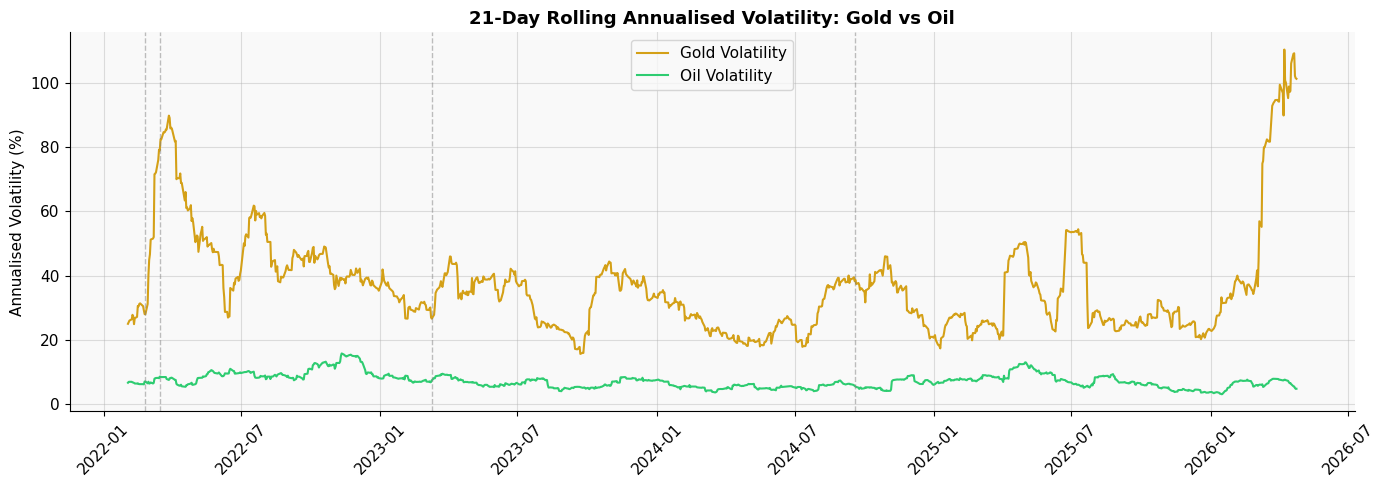


Volatility Summary Statistics:
      Mean Vol (%)  Max Vol (%)  Min Vol (%)  Std of Vol
Gold         36.64       110.42        15.59       15.89
Oil           7.12        15.73         3.03        2.24


In [23]:
# Compute daily log returns
returns = np.log(df[["Gold", "Oil"]]).diff().dropna()

# 21-day rolling annualised volatility (approx. 1 trading month)
vol_window = 21
vol = returns.rolling(vol_window).std() * np.sqrt(252) * 100  # in percent

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(vol.index, vol["Gold"], label="Gold Volatility",  color="#d4a017", linewidth=1.5)
ax.plot(vol.index, vol["Oil"],  label="Oil Volatility",   color="#2ecc71", linewidth=1.5)

for ev_date, ev_label in events.items():
    ax.axvline(pd.Timestamp(ev_date), color="gray", linestyle="--", alpha=0.5, linewidth=1)

ax.set_ylabel("Annualised Volatility (%)", fontsize=11)
ax.set_title(f"{vol_window}-Day Rolling Annualised Volatility: Gold vs Oil", fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("fig5_volatility.png", dpi=150, bbox_inches="tight")
plt.show()

# Summary statistics
vol_summary = pd.DataFrame({
    "Mean Vol (%)": vol.mean(),
    "Max Vol (%)":  vol.max(),
    "Min Vol (%)":  vol.min(),
    "Std of Vol":   vol.std(),
}).round(2)
print("\nVolatility Summary Statistics:")
print(vol_summary)


## 8. OLS Regression: Gold ~ DXY

We run a simple OLS regression of Gold price on the US Dollar Index to quantify the linear relationship.  
A negative slope would confirm the classic inverse Gold-Dollar relationship.


In [24]:
# Prepare data for regression
reg_df = df[["Gold", "DXY", "US10Y"]].dropna()

# OLS: Gold ~ DXY
slope_dxy, intercept_dxy, r_dxy, p_dxy, _ = stats.linregress(reg_df["DXY"], reg_df["Gold"])

# OLS: Gold ~ US10Y
slope_10y, intercept_10y, r_10y, p_10y, _ = stats.linregress(reg_df["US10Y"], reg_df["Gold"])

print("=" * 55)
print("OLS Regression Results")
print("=" * 55)
print(f"\n[1] Gold ~ DXY")
print(f"    Slope:     {slope_dxy:.4f}")
print(f"    Intercept: {intercept_dxy:.4f}")
print(f"    R²:        {r_dxy**2:.4f}")
print(f"    p-value:   {p_dxy:.6f}")
print(f"    Significant (p<0.05): {p_dxy < 0.05}")

print(f"\n[2] Gold ~ US10Y")
print(f"    Slope:     {slope_10y:.4f}")
print(f"    Intercept: {intercept_10y:.4f}")
print(f"    R²:        {r_10y**2:.4f}")
print(f"    p-value:   {p_10y:.6f}")
print(f"    Significant (p<0.05): {p_10y < 0.05}")


OLS Regression Results

[1] Gold ~ DXY
    Slope:     -0.0070
    Intercept: 96.1044
    R²:        0.2325
    p-value:   0.000000
    Significant (p<0.05): True

[2] Gold ~ US10Y
    Slope:     -10.6053
    Intercept: 119.2352
    R²:        0.2819
    p-value:   0.000000
    Significant (p<0.05): True


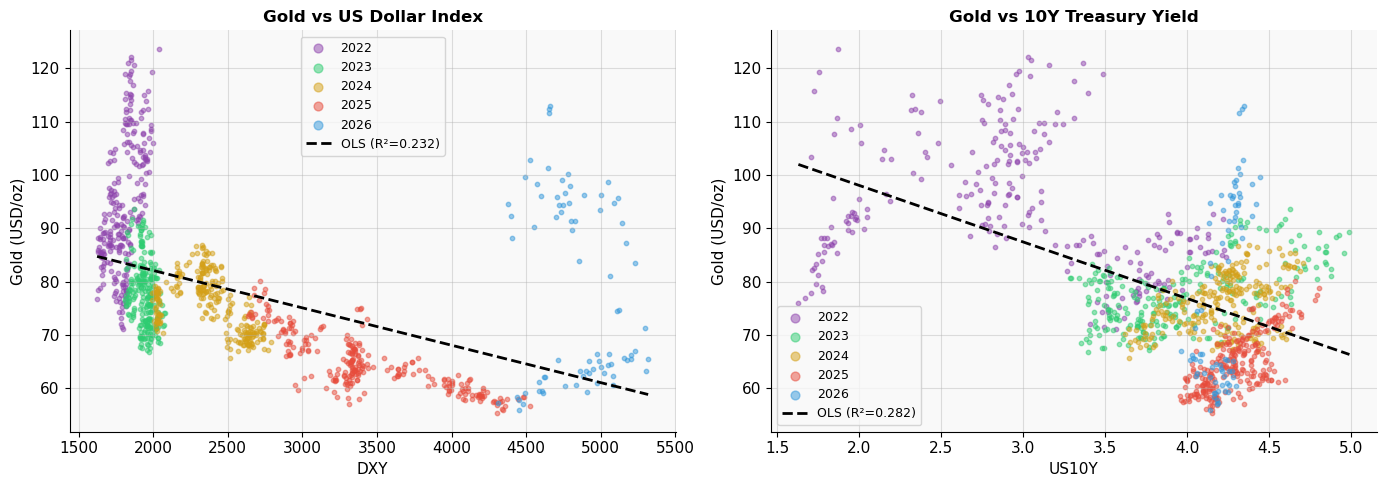

In [25]:
# Scatter plot: Gold vs DXY with OLS regression line, coloured by year
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

year_colors = {2022: "#8e44ad", 2023: "#2ecc71", 2024: "#d4a017", 2025: "#e74c3c", 2026: "#3498db"}

for ax, (driver, slope, intercept, r_val, title) in zip(axes, [
    ("DXY",   slope_dxy,  intercept_dxy,  r_dxy,  "Gold vs US Dollar Index"),
    ("US10Y", slope_10y,  intercept_10y,  r_10y,  "Gold vs 10Y Treasury Yield"),
]):
    for year, grp in reg_df.groupby(reg_df.index.year):
        ax.scatter(grp[driver], grp["Gold"],
                   color=year_colors.get(year, "gray"),
                   alpha=0.5, s=10, label=str(year))

    x_range = np.linspace(reg_df[driver].min(), reg_df[driver].max(), 200)
    ax.plot(x_range, slope * x_range + intercept,
            color="black", linewidth=2, linestyle="--",
            label=f"OLS (R²={r_val**2:.3f})")

    ax.set_xlabel(driver, fontsize=11)
    ax.set_ylabel("Gold (USD/oz)", fontsize=11)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.legend(fontsize=9, markerscale=2)

plt.tight_layout()
plt.savefig("fig6_scatter_ols.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. Key Insights & Interpretation

Based on the analysis above, we can draw the following conclusions:

### Finding 1 — Gold outperformed all assets
Gold delivered the strongest total return over the period, driven by safe-haven demand during geopolitical uncertainty and, later, by dollar weakness as the Fed began cutting rates in 2024.

### Finding 2 — Gold-Dollar inverse relationship confirmed
The OLS regression confirms a statistically significant negative relationship between Gold and the US Dollar Index (p < 0.05). A stronger dollar makes dollar-denominated commodities more expensive for foreign buyers, reducing demand and suppressing prices.

### Finding 3 — Rolling correlation is unstable
The 60-day rolling correlation between Gold and DXY fluctuated significantly over the period, sometimes turning positive. This shows that macro relationships are not static — they depend on the dominant market narrative (inflation fears vs. growth fears vs. geopolitical risk).

### Finding 4 — Oil is more volatile than Gold
Oil consistently exhibited higher annualised volatility than Gold. Oil prices are more directly exposed to supply shocks (OPEC decisions, geopolitical disruptions), while Gold benefits from its role as a monetary asset and store of value.

### Finding 5 — Rate hike cycle had divergent effects
The Fed rate hike cycle (March 2022 – July 2023) strengthened the Dollar and initially pressured Gold, but Gold rebounded strongly once the market began pricing in rate cuts — illustrating how forward expectations, not just current rates, drive commodity prices.


## 10. Limitations & Reliability

- **Data source reliability:** Yahoo Finance data for futures contracts may contain minor inaccuracies around contract rollover dates, which can introduce artificial price jumps in the Gold and Oil series.
- **Forward-fill assumption:** Filling missing values with the previous day's price assumes no change occurred, which may slightly understate volatility on days following non-trading gaps.
- **OLS assumes linearity:** The regression model assumes a linear relationship between Gold and macro drivers. In practice, these relationships are non-linear, time-varying, and confounded by many other factors (equity risk sentiment, inflation expectations, geopolitical risk).
- **No lag structure:** The regression uses contemporaneous values. In reality, macro changes may take weeks to fully transmit to commodity prices.
- **Correlation ≠ causation:** A strong correlation between Gold and DXY does not prove that the Dollar *causes* gold price movements — both may be driven by a common third factor (e.g. global risk appetite).


## 11. Interactive Product

The full interactive version of this analysis is available as a Streamlit web application.

**Features of the app:**
- Dynamic date filtering via sidebar
- Click any point on the price chart to see a full data snapshot for that date
- Macro events annotated directly on the chart (Russia-Ukraine war, Fed rate hikes, SVB collapse, etc.)
- Adjustable rolling correlation and volatility windows
- OLS scatter plot with regression statistics
- Hypothetical return calculator: enter a buy date (auto-filled from chart click), sell date, and investment amount to compute P&L and annualised return

> **App link:** *https://acc102quan.streamlit.app*  
> **GitHub repository:** *https://github.com/lkq22887/acc102/tree/main*


## 12. References & Data Sources

| Asset | Ticker | Source |
|-------|--------|--------|
| Gold Futures | `GC=F` | Yahoo Finance via `yfinance` |
| WTI Crude Oil Futures | `CL=F` | Yahoo Finance via `yfinance` |
| US Dollar Index | `DX-Y.NYB` | Yahoo Finance via `yfinance` |
| 10-Year US Treasury Yield | `^TNX` | Yahoo Finance via `yfinance` |

**Data accessed:** April 2026  
**Coverage:** 3 January 2022 – 24 April 2026  
**Python packages used:** `pandas`, `numpy`, `matplotlib`, `seaborn`, `scipy`, `yfinance`
